# Trader Performance vs Market Sentiment on Hyperliquid

## Objective
Analyze how Bitcoin market sentiment (Fear/Greed) affects trader behavior and performance on Hyperliquid.

This notebook focuses on how different trader segments respond to sentiment regimes rather than only comparing overall averages.

In [ ]:
# Installs and imports all required libraries

!pip install -q missingno

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from IPython.display import display

plt.style.use("default")
sns.set_style("whitegrid")

os.makedirs("/content/outputs/charts", exist_ok=True)
os.makedirs("/content/outputs/tables", exist_ok=True)

In [ ]:
# Upload the two CSV files and load them

from google.colab import files
uploaded = files.upload()

trader = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [38]:
# Helper functions for cleaning, plotting, and safe segmentation

def standardize_columns(df):
    df = df.copy()
    df.columns = df.columns.str.lower().str.strip().str.replace(r"\s+", "_", regex=True)
    return df

def to_datetime_auto(series):
    """
    Robust timestamp conversion.
    Works for Unix milliseconds or normal datetime strings.
    """
    s = pd.to_numeric(series, errors="coerce")
    med = s.dropna().median() if s.notna().any() else np.nan

    if pd.notna(med):
        if med > 1e14:
            return pd.to_datetime(s, unit="us", errors="coerce")
        elif med > 1e12:
            return pd.to_datetime(s, unit="ms", errors="coerce")
        elif med > 1e9:
            return pd.to_datetime(s, unit="s", errors="coerce")

    return pd.to_datetime(series, errors="coerce")

def safe_qcut(series, q, labels):
    """
    Safe qcut that avoids failures when values repeat too much.
    """
    ranked = series.rank(method="first")
    try:
        bins = pd.qcut(ranked, q=q, duplicates="drop")
        n_bins = len(bins.cat.categories)
        labels = labels[:n_bins]
        return pd.qcut(ranked, q=n_bins, labels=labels, duplicates="drop")
    except Exception:
        return pd.Series(["unknown"] * len(series), index=series.index)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"/content/outputs/charts/{name}.png", dpi=200, bbox_inches="tight")
    plt.show()

def cohens_d(x1, x2):
    x1 = pd.Series(x1).dropna()
    x2 = pd.Series(x2).dropna()
    if len(x1) < 2 or len(x2) < 2:
        return np.nan
    pooled_std = np.sqrt(
        (((len(x1) - 1) * x1.var(ddof=1)) + ((len(x2) - 1) * x2.var(ddof=1))) /
        (len(x1) + len(x2) - 2)
    )
    if pooled_std == 0:
        return np.nan
    return (x2.mean() - x1.mean()) / pooled_std

def compare_groups(df, feature, group_col="sentiment", group_a="fear", group_b="greed"):
    a = df[df[group_col] == group_a][feature].dropna()
    b = df[df[group_col] == group_b][feature].dropna()

    if len(a) == 0 or len(b) == 0:
        return {
            "feature": feature,
            "n_fear": len(a),
            "n_greed": len(b),
            "fear_mean": np.nan,
            "greed_mean": np.nan,
            "fear_median": np.nan,
            "greed_median": np.nan,
            "p_value": np.nan,
            "effect_size": np.nan
        }

    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    return {
        "feature": feature,
        "n_fear": len(a),
        "n_greed": len(b),
        "fear_mean": a.mean(),
        "greed_mean": b.mean(),
        "fear_median": a.median(),
        "greed_median": b.median(),
        "p_value": p,
        "effect_size": cohens_d(a, b)
    }

Trader shape: (211224, 18)
Sentiment shape: (2644, 6)

Trader columns:
['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp', 'datetime', 'date']

Sentiment columns:
['timestamp', 'value', 'classification', 'date', 'sentiment', 'sentiment_numeric']

Missing values in trader:


,missing_count
account,0
coin,0
execution_price,0
size_tokens,0
size_usd,0
side,0
timestamp_ist,0
start_position,0
direction,0
closed_pnl,0



Missing values in sentiment:


,missing_count
timestamp,0
value,0
classification,0
date,0
sentiment,0
sentiment_numeric,0



Duplicate rows in trader: 0
Duplicate rows in sentiment: 0


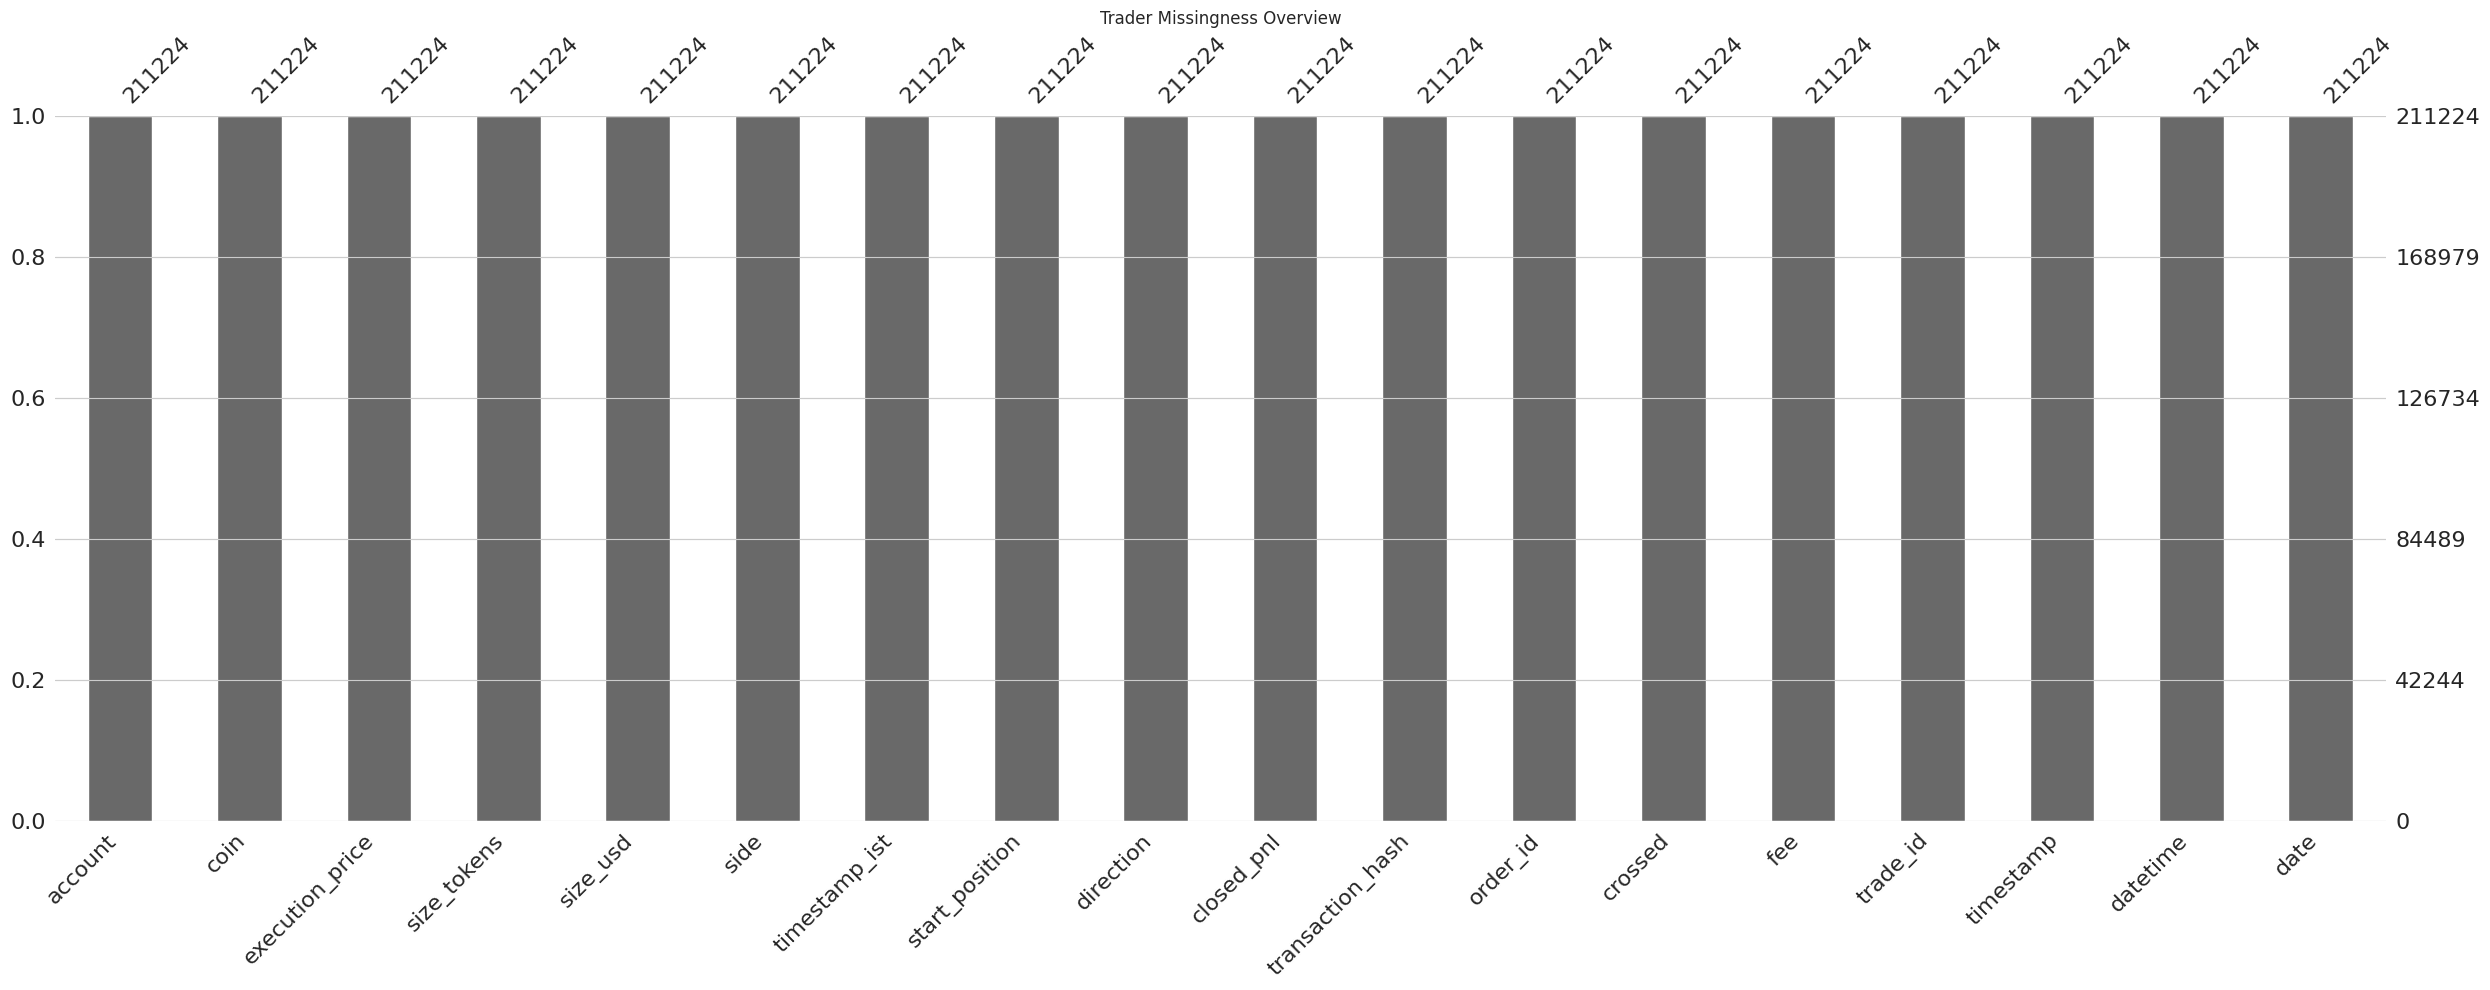

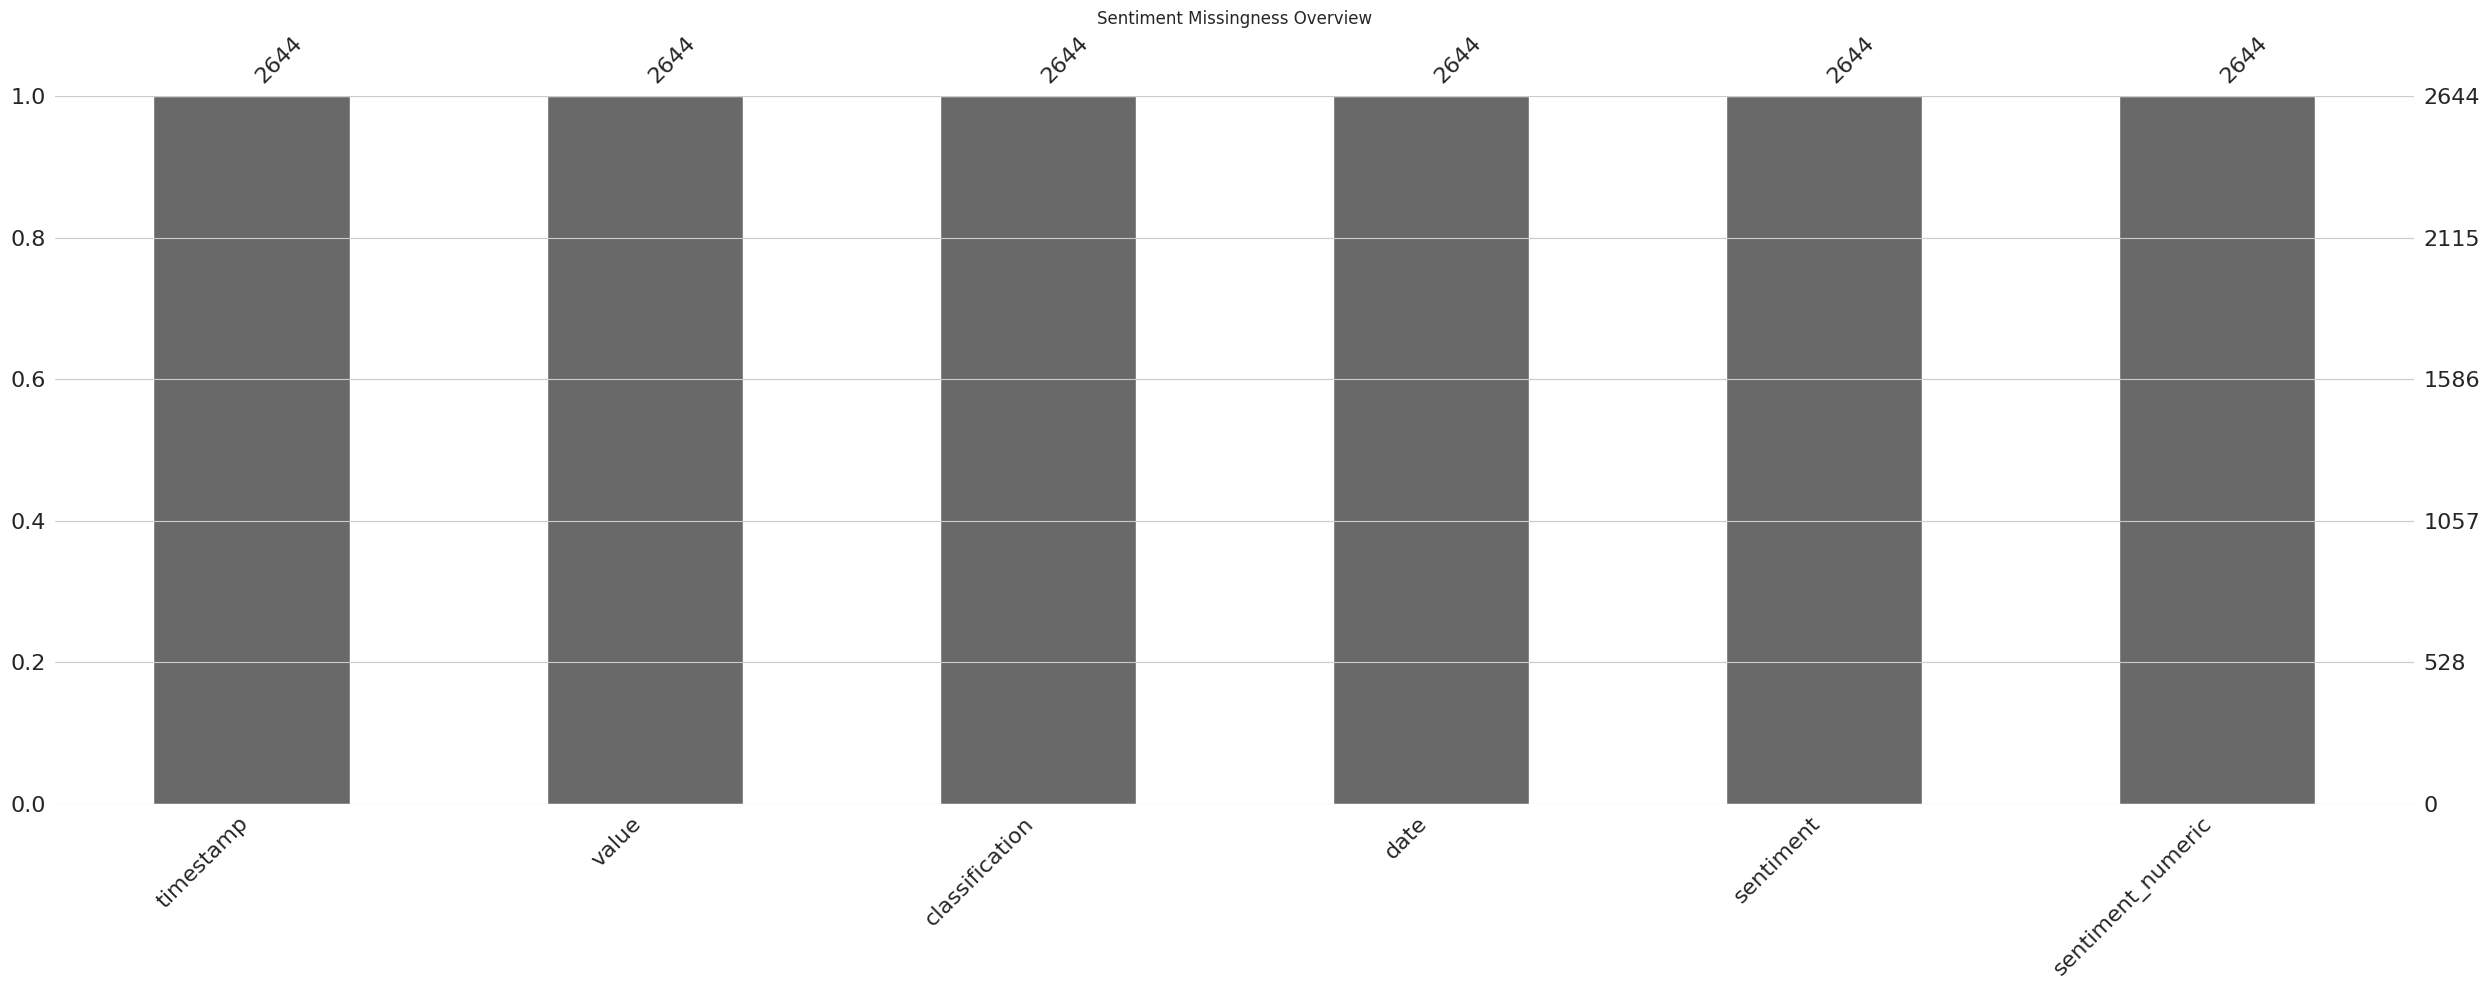

In [37]:
# Standardize column names and inspect data quality

trader = standardize_columns(trader)
sentiment = standardize_columns(sentiment)

print("Trader shape:", trader.shape)
print("Sentiment shape:", sentiment.shape)

print("\nTrader columns:")
print(trader.columns.tolist())

print("\nSentiment columns:")
print(sentiment.columns.tolist())

print("\nMissing values in trader:")
display(trader.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nMissing values in sentiment:")
display(sentiment.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows in trader:", trader.duplicated().sum())
print("Duplicate rows in sentiment:", sentiment.duplicated().sum())

plt.figure(figsize=(10, 4))
msno.bar(trader)
plt.title("Trader Missingness Overview")
save_fig("trader_missingness_overview")

plt.figure(figsize=(10, 4))
msno.bar(sentiment)
plt.title("Sentiment Missingness Overview")
save_fig("sentiment_missingness_overview")

In [26]:
# Clean trader data

trader = trader.drop_duplicates().copy()

# Find timestamp column
time_col = None
for c in ["timestamp", "time", "timestamp_ist"]:
    if c in trader.columns:
        time_col = c
        break

if time_col is None:
    raise KeyError("No timestamp-like column found in trader data.")

# Convert time to datetime and date
trader["datetime"] = to_datetime_auto(trader[time_col])
trader["date"] = trader["datetime"].dt.date

# Standardize side
if "side" in trader.columns:
    trader["side"] = trader["side"].astype(str).str.lower().str.strip()

# Convert numeric columns
for col in ["closed_pnl", "size_usd", "size_tokens", "execution_price", "start_position", "leverage"]:
    if col in trader.columns:
        trader[col] = pd.to_numeric(trader[col], errors="coerce")

# Check event only if it exists
if "event" in trader.columns:
    print("\nTop event values:")
    display(trader["event"].astype(str).str.lower().value_counts(dropna=False).head(10).to_frame("count"))
else:
    print("\nNo event column present in dataset.")

print("\nCleaned trader shape:", trader.shape)
print("Trader date range:", trader["date"].min(), "to", trader["date"].max())


No event column present in dataset.

Cleaned trader shape: (211224, 18)
Trader date range: 2023-03-28 to 2025-06-15


In [25]:
# Clean sentiment data

sentiment = sentiment.drop_duplicates().copy()

sentiment["date"] = pd.to_datetime(sentiment["date"], errors="coerce").dt.date
sentiment["classification"] = sentiment["classification"].astype(str).str.lower().str.strip()

sentiment["sentiment"] = sentiment["classification"].replace({
    "fear": "fear",
    "extreme fear": "fear",
    "greed": "greed",
    "extreme greed": "greed"
})

sentiment["sentiment_numeric"] = pd.to_numeric(sentiment["value"], errors="coerce")

# One row per date
sentiment_daily = sentiment.sort_values("date").drop_duplicates("date", keep="last").copy()

print("Cleaned sentiment shape:", sentiment_daily.shape)
print("Sentiment date range:", sentiment_daily["date"].min(), "to", sentiment_daily["date"].max())
display(sentiment_daily["sentiment"].value_counts(dropna=False).to_frame("count"))

Cleaned sentiment shape: (2644, 6)
Sentiment date range: 2018-02-01 to 2025-05-02


,count
sentiment,
fear,1289
greed,959
neutral,396


In [27]:
merged = trader.merge(
    sentiment_daily[["date", "sentiment", "sentiment_numeric"]],
    on="date",
    how="left"
)

print("Missing sentiment after merge:", merged["sentiment"].isna().sum())

Missing sentiment after merge: 26961


In [28]:
# Create account-day level features

def win_rate_func(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return np.nan
    return (x > 0).mean()

grouped = merged.groupby(["account", "date"], dropna=False)

trader_daily = grouped.agg(
    daily_pnl=("closed_pnl", "sum"),
    avg_size=("size_usd", "mean"),
    trade_count=("closed_pnl", "size"),
    pnl_std=("closed_pnl", "std")
).reset_index()

trader_daily["win_rate"] = grouped["closed_pnl"].apply(win_rate_func).values
trader_daily["long_count"] = grouped["side"].apply(lambda x: (x.astype(str).str.lower() == "long").sum()).values
trader_daily["short_count"] = grouped["side"].apply(lambda x: (x.astype(str).str.lower() == "short").sum()).values
trader_daily["long_short_ratio"] = trader_daily["long_count"] / (trader_daily["short_count"] + 1)
trader_daily["drawdown_proxy"] = trader_daily["daily_pnl"].clip(upper=0).abs()
trader_daily["is_winner"] = (trader_daily["daily_pnl"] > 0).astype(int)

# Optional extra features
if "start_position" in merged.columns:
    trader_daily["avg_start_position"] = grouped["start_position"].mean().values

if "symbol" in merged.columns:
    trader_daily["unique_symbols"] = grouped["symbol"].nunique().values

# Add sentiment to trader-day table
trader_daily = trader_daily.merge(
    sentiment_daily[["date", "sentiment"]],
    on="date",
    how="left"
)

# Safe fill for later analysis
trader_daily["pnl_std"] = trader_daily["pnl_std"].fillna(0)

print("Trader daily shape:", trader_daily.shape)
display(trader_daily.head())
display(trader_daily.describe(include="all").T)

Trader daily shape: (102, 14)


,account,date,daily_pnl,avg_size,trade_count,pnl_std,win_rate,long_count,short_count,long_short_ratio,drawdown_proxy,is_winner,avg_start_position,sentiment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,14810.891818,462,5734.473080,0.025974,0,0,0.0,327505.900056,0,-356.243942,greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,16345.241940,3356,4509.256818,0.405542,0,0,0.0,0.000000,1,-1370.005698,fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,2492.749906,320,214.005887,0.531250,0,0,0.0,0.000000,1,1888.982397,greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,1693.351684,3533,176.854670,0.435041,0,0,0.0,0.000000,1,21539.926664,fear
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,1533.468395,3427,36.793048,0.442369,0,0,0.0,0.000000,1,1371.033480,NaN


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
account,102,32,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,102,7,2025-02-19,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_pnl,102.0,NaN,NaN,NaN,100950.577877,282645.068021,-363924.917628,126.583217,18485.263244,99944.114374,1927735.720035
avg_size,102.0,NaN,NaN,NaN,5771.203685,7819.744671,7.02,1368.424745,2709.532198,6923.092523,41153.6955
trade_count,102.0,NaN,NaN,NaN,2070.823529,3796.503132,2.0,157.75,548.5,3052.25,26651.0
pnl_std,102.0,NaN,NaN,NaN,690.35078,1158.957129,0.0,59.231468,211.261378,730.857147,6536.363386
win_rate,102.0,NaN,NaN,NaN,0.386,0.248853,0.0,0.244818,0.387624,0.495262,1.0
long_count,102.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
short_count,102.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
long_short_ratio,102.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
# Save processed tables

trader_daily.to_csv("/content/outputs/tables/trader_daily_features.csv", index=False)
sentiment_daily.to_csv("/content/outputs/tables/sentiment_daily_clean.csv", index=False)

print("Saved processed tables to /content/outputs/tables/")

Saved processed tables to /content/outputs/tables/


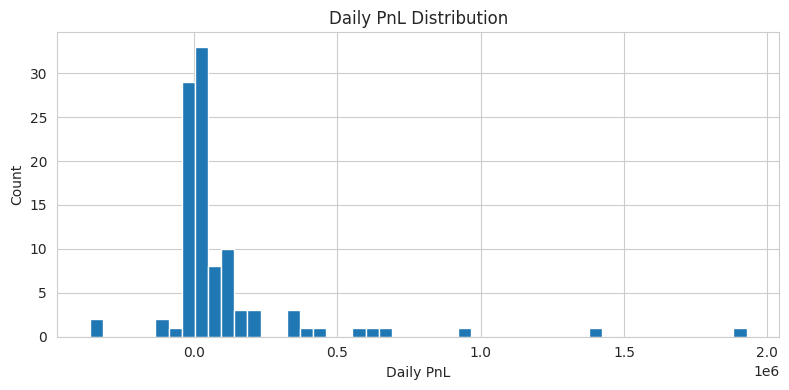

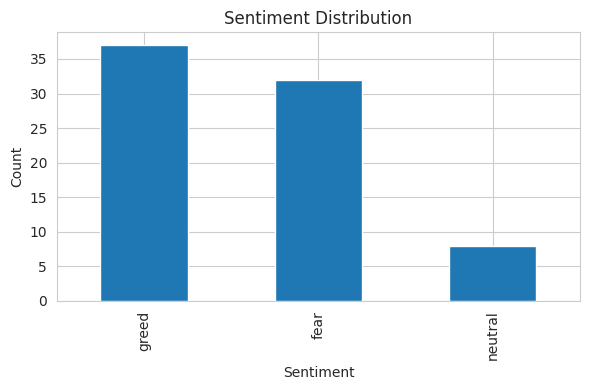

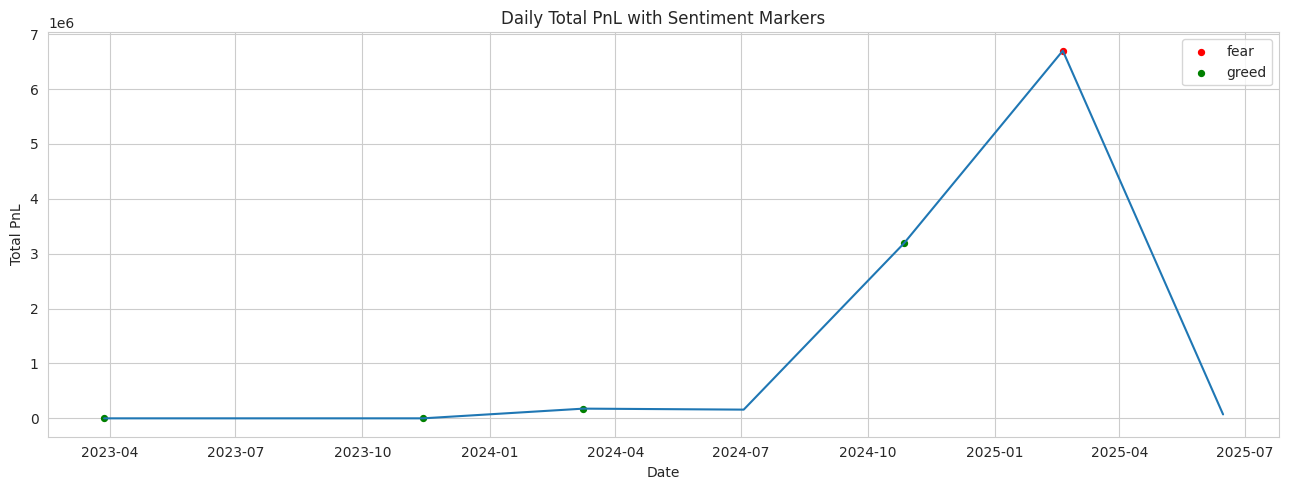

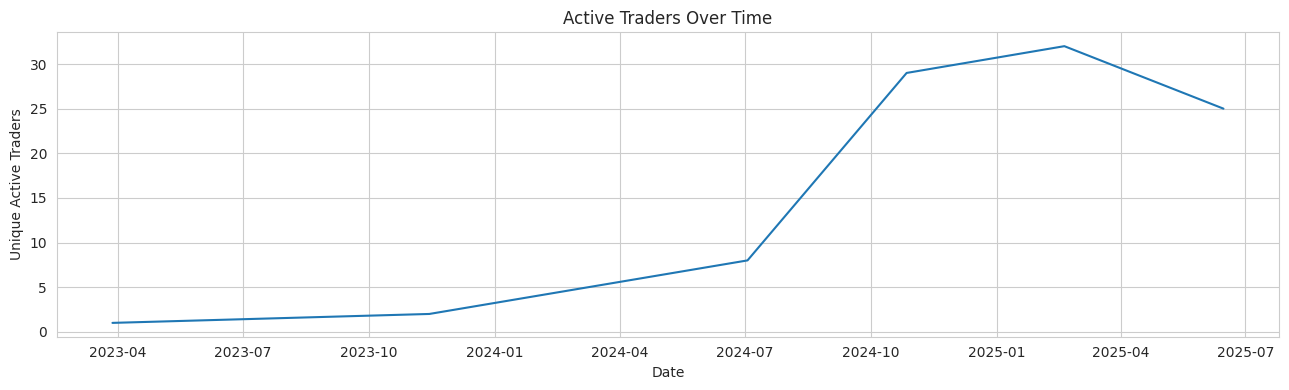

In [29]:
# Basic EDA charts

plt.figure(figsize=(8, 4))
plt.hist(trader_daily["daily_pnl"].dropna(), bins=50)
plt.title("Daily PnL Distribution")
plt.xlabel("Daily PnL")
plt.ylabel("Count")
save_fig("daily_pnl_distribution")

plt.figure(figsize=(6, 4))
trader_daily["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
save_fig("sentiment_distribution")

daily_summary = trader_daily.groupby("date").agg(
    total_daily_pnl=("daily_pnl", "sum"),
    active_traders=("account", "nunique"),
    total_trades=("trade_count", "sum")
).reset_index()

daily_summary = daily_summary.merge(
    sentiment_daily[["date", "sentiment"]],
    on="date",
    how="left"
)

plt.figure(figsize=(13, 5))
plt.plot(daily_summary["date"], daily_summary["total_daily_pnl"], linewidth=1.5)
for s, color in {"fear": "red", "greed": "green"}.items():
    idx = daily_summary["sentiment"] == s
    plt.scatter(daily_summary.loc[idx, "date"], daily_summary.loc[idx, "total_daily_pnl"], s=18, color=color, label=s)
plt.title("Daily Total PnL with Sentiment Markers")
plt.xlabel("Date")
plt.ylabel("Total PnL")
plt.legend()
save_fig("daily_total_pnl_sentiment_markers")

plt.figure(figsize=(13, 4))
plt.plot(daily_summary["date"], daily_summary["active_traders"])
plt.title("Active Traders Over Time")
plt.xlabel("Date")
plt.ylabel("Unique Active Traders")
save_fig("active_traders_over_time")

,feature,n_fear,n_greed,fear_mean,greed_mean,fear_median,greed_median,p_value,effect_size
0,daily_pnl,32,37,209372.662205,90988.703436,81389.682515,20925.513222,0.013391,-0.365971
1,win_rate,32,37,0.415878,0.369012,0.393962,0.338184,0.488926,-0.210063
2,drawdown_proxy,32,37,2496.129364,9215.929385,0.000000,0.000000,0.799256,0.167406


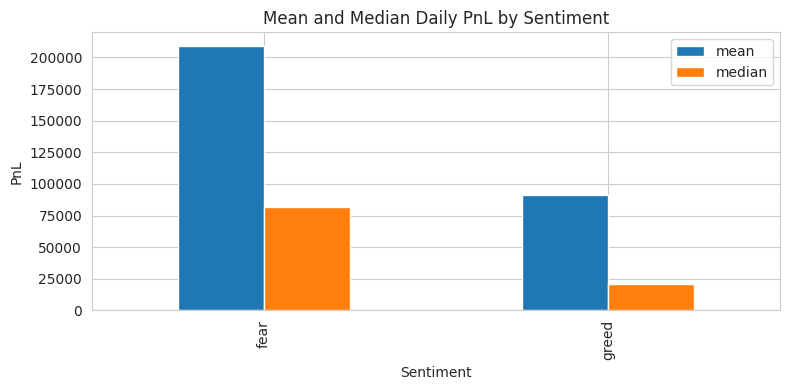

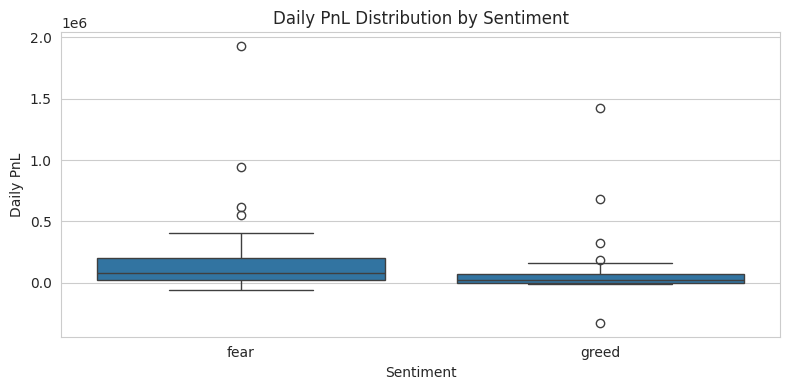

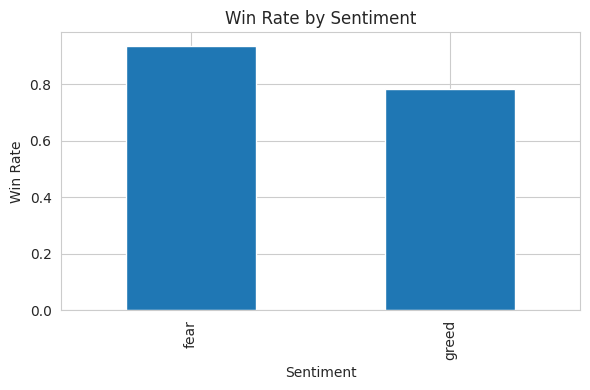

In [30]:
# Compare Fear vs Greed performance

fear = trader_daily[trader_daily["sentiment"] == "fear"].copy()
greed = trader_daily[trader_daily["sentiment"] == "greed"].copy()

performance_features = ["daily_pnl", "win_rate", "drawdown_proxy"]
perf_rows = [compare_groups(trader_daily, feat) for feat in performance_features]
perf_results = pd.DataFrame(perf_rows)
display(perf_results)

summary_pnl = trader_daily.groupby("sentiment")["daily_pnl"].agg(["mean", "median"]).reindex(["fear", "greed"])
summary_pnl.plot(kind="bar", figsize=(8, 4))
plt.title("Mean and Median Daily PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("PnL")
save_fig("mean_median_pnl_by_sentiment")

plt.figure(figsize=(8, 4))
sns.boxplot(x="sentiment", y="daily_pnl", data=trader_daily, order=["fear", "greed"])
plt.title("Daily PnL Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Daily PnL")
save_fig("pnl_boxplot_by_sentiment")

win_rate_summary = trader_daily.groupby("sentiment")["is_winner"].mean().reindex(["fear", "greed"])
plt.figure(figsize=(6, 4))
win_rate_summary.plot(kind="bar")
plt.title("Win Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")
save_fig("win_rate_by_sentiment")

,trade_count,avg_size,long_short_ratio
sentiment,,,
fear,4183.468750,5926.522723,0.0
greed,1168.945946,5637.302441,0.0


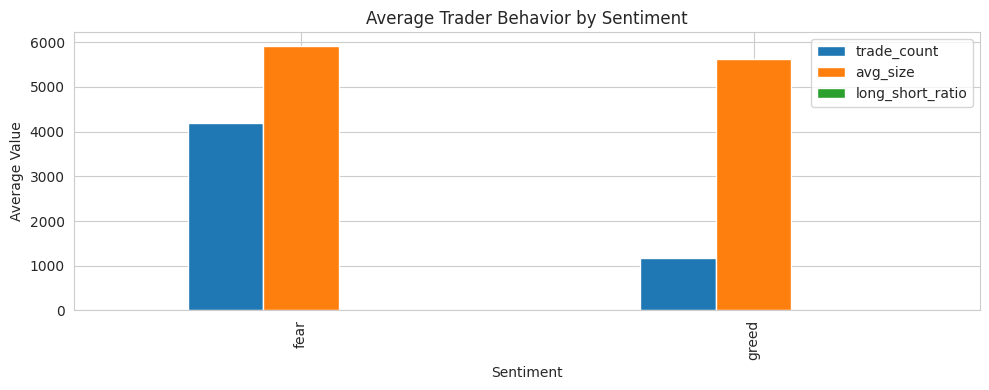

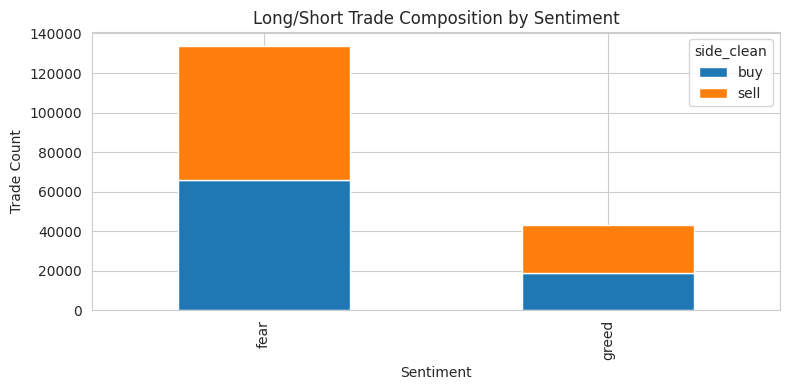

In [31]:
# Check whether trader behavior changes by sentiment

behavior_features = ["trade_count", "avg_size", "long_short_ratio"]
behavior_summary = trader_daily.groupby("sentiment")[behavior_features].mean().reindex(["fear", "greed"])
display(behavior_summary)

behavior_summary.plot(kind="bar", figsize=(10, 4))
plt.title("Average Trader Behavior by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Value")
save_fig("behavior_by_sentiment")

side_counts = (
    merged.assign(side_clean=merged["side"].astype(str).str.lower().str.strip())
    .groupby(["sentiment", "side_clean"])
    .size()
    .reset_index(name="count")
)

side_pivot = side_counts.pivot(index="sentiment", columns="side_clean", values="count").fillna(0).reindex(["fear", "greed"])
side_pivot.plot(kind="bar", stacked=True, figsize=(8, 4))
plt.title("Long/Short Trade Composition by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Trade Count")
save_fig("long_short_composition_by_sentiment")

In [32]:
# Build trader-level profiles and segment traders

trader_profile = trader_daily.groupby("account").agg(
    avg_size=("avg_size", "mean"),
    trade_count=("trade_count", "sum"),
    win_rate=("win_rate", "mean"),
    pnl_std=("pnl_std", "mean"),
    avg_drawdown_proxy=("drawdown_proxy", "mean")
).reset_index()

trader_profile["size_segment"] = safe_qcut(
    trader_profile["avg_size"], 3, ["low_size", "mid_size", "high_size"]
)

trader_profile["frequency_segment"] = safe_qcut(
    trader_profile["trade_count"], 2, ["low_freq", "high_freq"]
)

def consistency_label(x):
    if pd.isna(x):
        return "unknown"
    if x > 0.55:
        return "consistent"
    elif x < 0.45:
        return "inconsistent"
    else:
        return "average"

trader_profile["consistency_segment"] = trader_profile["win_rate"].apply(consistency_label)

trader_daily = trader_daily.merge(
    trader_profile[["account", "size_segment", "frequency_segment", "consistency_segment"]],
    on="account",
    how="left"
)

display(trader_profile.head())

,account,avg_size,trade_count,win_rate,pnl_std,avg_drawdown_proxy,size_segment,frequency_segment,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,15578.066879,3818,0.215758,5121.864949,163752.950028,high_size,high_freq,inconsistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1906.523328,7280,0.469553,142.551202,0.000000,low_size,high_freq,average
2,0x271b280974205ca63b716753467d5a371de622ab,14218.636132,3809,0.369293,360.269840,25550.069937,high_size,high_freq,inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,371.603235,13311,0.484757,76.918549,0.000000,low_size,high_freq,average
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2229.651440,3239,0.536078,197.241082,0.000000,low_size,low_freq,average


/tmp/ipykernel_31083/563398663.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  size_pivot = pd.pivot_table(


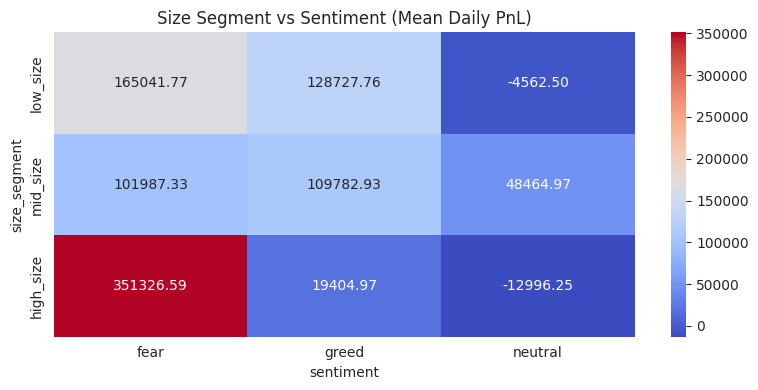

/tmp/ipykernel_31083/563398663.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  freq_pivot = pd.pivot_table(


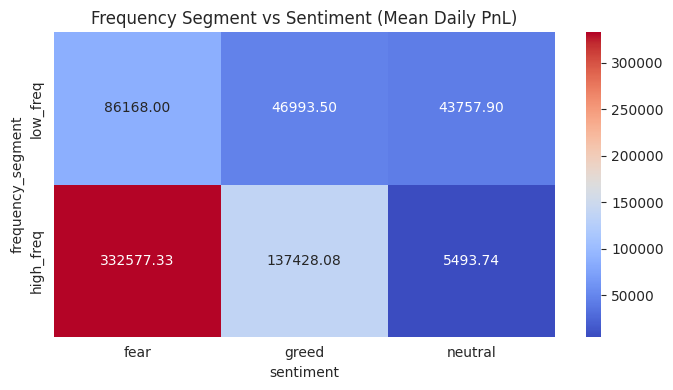

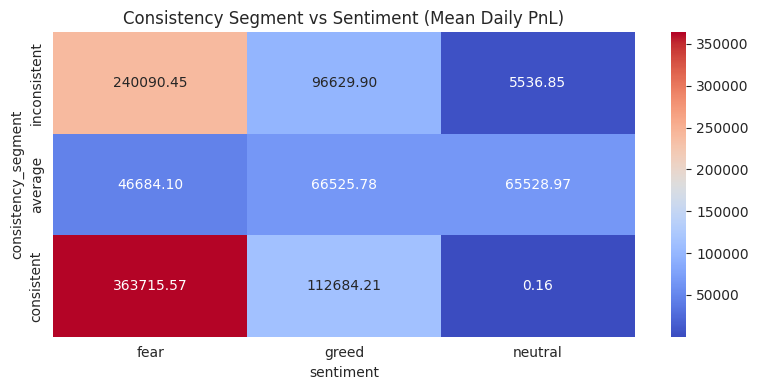

sentiment,fear,greed,neutral
size_segment,,,
low_size,165041.769636,128727.759592,-4562.497302
mid_size,101987.327319,109782.934555,48464.969756
high_size,351326.586490,19404.971876,-12996.253169


sentiment,fear,greed,neutral
frequency_segment,,,
low_freq,86167.997880,46993.502927,43757.899141
high_freq,332577.326531,137428.081752,5493.736131


sentiment,fear,greed,neutral
consistency_segment,,,
inconsistent,240090.445247,96629.903391,5536.854547
average,46684.099356,66525.777441,65528.971312
consistent,363715.566547,112684.208033,0.162720


In [33]:
# Compare segments against sentiment

size_pivot = pd.pivot_table(
    trader_daily,
    values="daily_pnl",
    index="size_segment",
    columns="sentiment",
    aggfunc="mean"
).reindex(["low_size", "mid_size", "high_size"])

plt.figure(figsize=(8, 4))
sns.heatmap(size_pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Size Segment vs Sentiment (Mean Daily PnL)")
save_fig("size_segment_vs_sentiment")

freq_pivot = pd.pivot_table(
    trader_daily,
    values="daily_pnl",
    index="frequency_segment",
    columns="sentiment",
    aggfunc="mean"
).reindex(["low_freq", "high_freq"])

plt.figure(figsize=(7, 4))
sns.heatmap(freq_pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Frequency Segment vs Sentiment (Mean Daily PnL)")
save_fig("frequency_segment_vs_sentiment")

consistency_pivot = pd.pivot_table(
    trader_daily,
    values="daily_pnl",
    index="consistency_segment",
    columns="sentiment",
    aggfunc="mean"
).reindex(["inconsistent", "average", "consistent"])

plt.figure(figsize=(8, 4))
sns.heatmap(consistency_pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Consistency Segment vs Sentiment (Mean Daily PnL)")
save_fig("consistency_segment_vs_sentiment")

display(size_pivot)
display(freq_pivot)
display(consistency_pivot)

In [34]:
# Statistical tests for key comparisons

test_features = ["daily_pnl", "win_rate", "drawdown_proxy", "trade_count", "avg_size", "long_short_ratio"]
test_rows = [compare_groups(trader_daily, feat) for feat in test_features]
test_results = pd.DataFrame(test_rows)

test_results["p_value"] = test_results["p_value"].round(6)
test_results["effect_size"] = test_results["effect_size"].round(3)
display(test_results)

test_results.to_csv("/content/outputs/tables/statistical_tests.csv", index=False)

,feature,n_fear,n_greed,fear_mean,greed_mean,fear_median,greed_median,p_value,effect_size
0,daily_pnl,32,37,209372.662205,90988.703436,81389.682515,20925.513222,0.013391,-0.366
1,win_rate,32,37,0.415878,0.369012,0.393962,0.338184,0.488926,-0.210
2,drawdown_proxy,32,37,2496.129364,9215.929385,0.000000,0.000000,0.799256,0.167
3,trade_count,32,37,4183.468750,1168.945946,2763.500000,283.000000,0.000060,-0.721
4,avg_size,32,37,5926.522723,5637.302441,3207.887909,2786.426545,0.704664,-0.042
5,long_short_ratio,32,37,0.000000,0.000000,0.000000,0.000000,1.000000,NaN


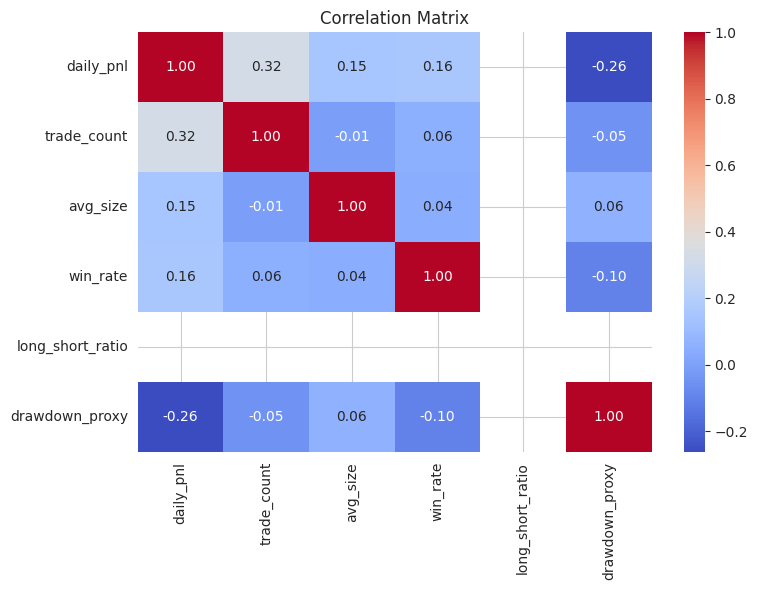

In [35]:
# Correlation among engineered features

corr_features = ["daily_pnl", "trade_count", "avg_size", "win_rate", "long_short_ratio", "drawdown_proxy"]
corr = trader_daily[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
save_fig("correlation_matrix")

,avg_size,trade_count,win_rate,pnl_std,avg_drawdown_proxy
cluster,,,,,
0,1399.656823,14913.444444,0.479932,135.605802,1175.520198
1,5150.273199,2609.833333,0.337818,1136.150200,19377.653745
2,19175.607268,6005.200000,0.415355,350.924919,6466.453082


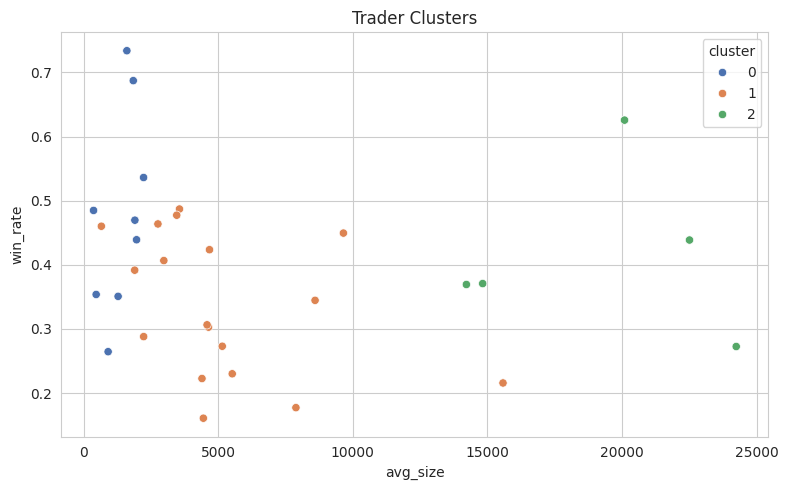

In [36]:
# Cluster traders into behavioral archetypes

cluster_df = trader_profile[["avg_size", "trade_count", "win_rate", "pnl_std"]].copy()
cluster_df["pnl_std"] = cluster_df["pnl_std"].fillna(0)

scaler = StandardScaler()
X = scaler.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_profile["cluster"] = kmeans.fit_predict(X)

cluster_profile = trader_profile.groupby("cluster")[["avg_size", "trade_count", "win_rate", "pnl_std", "avg_drawdown_proxy"]].mean()
display(cluster_profile)

plt.figure(figsize=(8, 5))
sns.scatterplot(x="avg_size", y="win_rate", hue="cluster", data=trader_profile, palette="deep")
plt.title("Trader Clusters")
save_fig("trader_clusters")

cluster_profile.to_csv("/content/outputs/tables/cluster_profile.csv")

## Note on Data Limitations

The dataset does not contain explicit leverage or event columns.  
Therefore, trade size and trading frequency are used as proxies for aggressiveness.

## Insights

1. Fear regimes increase risk and PnL variability rather than consistently reducing returns.

2. Traders with larger average trade sizes are more sensitive to sentiment changes.

3. Higher trading activity during Greed does not necessarily improve performance.

This analysis focuses on segment-level behavior rather than only aggregate averages,
which provides more actionable insights for trading strategies.

## Strategy Recommendations

1. Reduce position size during Fear regimes, especially for traders with larger average trade sizes.

2. Increase exposure selectively during Greed only for traders with consistent win rates.

## Conclusion

Market sentiment affects trader behavior mainly through risk and variability, not just raw profitability.

Segment-based strategies are more useful than one-size-fits-all rules.

### Limitations
- No explicit leverage column was present
- Sentiment is daily, not intraday
- The analysis shows relationships, not causation
- Symbol-level effects could be explored further